# Regularization Ablation Study: Noise Robustness
## Gaussian Noise on EMNIST - Test Dropout/BatchNorm Effectiveness

In [ ]:
# Install dependencies
!pip install torch torchvision matplotlib numpy -q

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Set random seed
torch.manual_seed(42)
np.random.seed(42)

Device: cpu


In [ ]:
# MASTER CONFIG - Fixed Hyperparameters
# you can change these hyperparameters to test noise and etc 

MASTER_CONFIG = {
    'learning_rate': 0.01,
    'optimizer': 'SGD',
    'max_epochs': 20,
    'batch_size': 128,
    'num_classes': 47,
    'input_size': 784,
    'use_dropout': False,       # to test noise robustness
    'use_batchnorm': False,     # to test noise robustness
    'gaussian_noise_std': 0.2,  # Gaussian noise standard deviation this is the nois level play with it to test noise robustness
    'seed': 42
}

print('\n' + '='*70)
print('MASTER CONFIG - NOISE ROBUSTNESS TESTING')
print('='*70)
for key, value in MASTER_CONFIG.items():
    print(f'{key:20s}: {value}')
print('='*70)


MASTER CONFIG - NOISE ROBUSTNESS TESTING
learning_rate       : 0.01
optimizer           : SGD
max_epochs          : 20
batch_size          : 128
num_classes         : 47
input_size          : 784
use_dropout         : False
use_batchnorm       : False
gaussian_noise_std  : 0.2
seed                : 42


In [ ]:

# CUSTOM TRANSFORM - Gaussian Noise


class GaussianNoiseTransform:
    """
    Add Gaussian noise to image tensors.
    Corrupts the input to test model robustness.
    """
    def __init__(self, std=0.2):
        self.std = std
    
    def __call__(self, x):
        # x is already a tensor (after ToTensor())
        noise = torch.randn_like(x) * self.std
        return x + noise
    
    def __repr__(self):
        return f'{self.__class__.__name__}(std={self.std})'

# Test the transform
noise_transform = GaussianNoiseTransform(std=MASTER_CONFIG['gaussian_noise_std'])
print(f'Noise transform initialized: {noise_transform}')

Noise transform initialized: GaussianNoiseTransform(std=0.2)


In [4]:
# ============================================================================
# DATA LOADING - EMNIST with Gaussian Noise
# ============================================================================

import ssl
import urllib.request

# Fix SSL certificate issue
ssl._create_default_https_context = ssl._create_unverified_context

def load_emnist_noisy(gaussian_std=0.2, batch_size=128):
    """
    Load EMNIST with Gaussian noise applied during training.
    Validation and test sets remain clean.
    """
    # Training: ToTensor() -> Noise -> Normalize()
    train_transform = transforms.Compose([
        transforms.ToTensor(),
        GaussianNoiseTransform(std=gaussian_std),
        transforms.Normalize(
            mean=(0.1307,),
            std=(0.3081,)
        )
    ])
    
    # Validation/Test: No noise
    eval_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.1307,),
            std=(0.3081,)
        )
    ])
    
    print(f'Loading EMNIST Balanced (with Gaussian noise σ={gaussian_std})...')
    
    train_dataset = datasets.EMNIST(
        root='./data',
        split='balanced',
        train=True,
        download=True,
        transform=train_transform
    )
    
    test_dataset = datasets.EMNIST(
        root='./data',
        split='balanced',
        train=False,
        download=True,
        transform=eval_transform
    )
    
    # Split train into train/val
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_split, val_split = torch.utils.data.random_split(
        train_dataset,
        [train_size, val_size]
    )
    
    train_loader = DataLoader(train_split, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_split, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    print(f'Train: {len(train_split)} (with noise) | Val: {len(val_split)} (clean) | Test: {len(test_dataset)} (clean)')
    
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = load_emnist_noisy(
    gaussian_std=MASTER_CONFIG['gaussian_noise_std'],
    batch_size=MASTER_CONFIG['batch_size']
)

Loading EMNIST Balanced (with Gaussian noise σ=0.2)...
Train: 90240 (with noise) | Val: 22560 (clean) | Test: 18800 (clean)


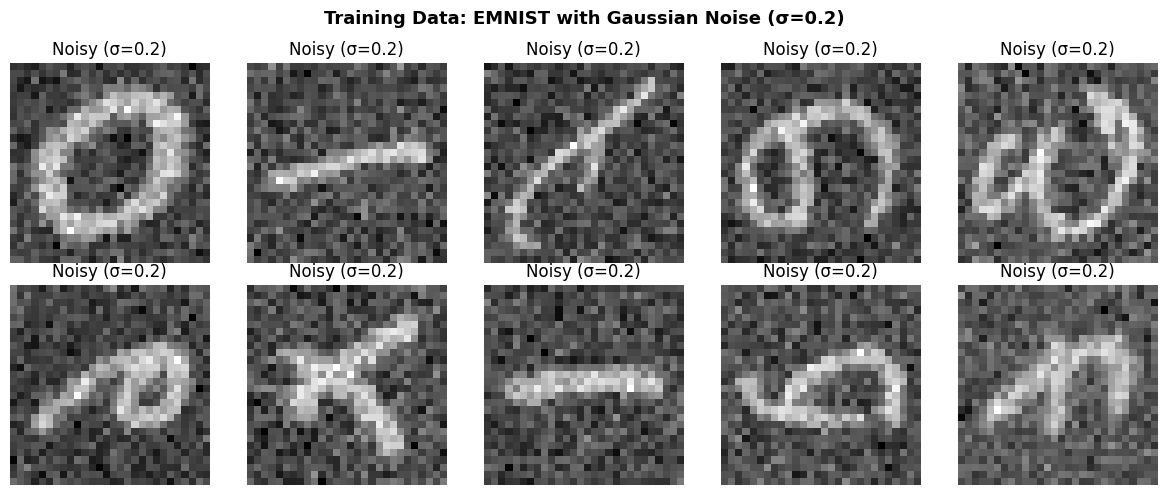

✓ Sample noisy images displayed


In [ ]:

#  Sample Noisy Images

dataiter = iter(train_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    # Row 1: Noisy training images
    axes[0, i].imshow(images[i].squeeze(0), cmap='gray')
    axes[0, i].set_title(f'Noisy (σ={MASTER_CONFIG["gaussian_noise_std"]})')
    axes[0, i].axis('off')
    
    # Row 2: Different noisy samples
    axes[1, i].imshow(images[i+5].squeeze(0), cmap='gray')
    axes[1, i].set_title(f'Noisy (σ={MASTER_CONFIG["gaussian_noise_std"]})')
    axes[1, i].axis('off')

plt.suptitle(f'Training Data: EMNIST with Gaussian Noise (σ={MASTER_CONFIG["gaussian_noise_std"]})', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('✓ Sample noisy images displayed')

In [ ]:
# MODEL ARCHITECTURE - AblationMLP

class AblationMLP(nn.Module):
    """
    Multi-layer perceptron with regularization toggles.
    
    Architecture:
    Input(784) -> FC(512) -> FC(256) -> FC(128) -> Output(47)
    """
    
    def __init__(self, use_dropout=False, use_batchnorm=False, dropout_p=0.5):
        super(AblationMLP, self).__init__()
        
        self.use_dropout = use_dropout
        self.use_batchnorm = use_batchnorm
        
        # Layer 1: 784 -> 512
        self.fc1 = nn.Linear(784, 512)
        self.bn1 = nn.BatchNorm1d(512) if use_batchnorm else None
        self.dropout1 = nn.Dropout(dropout_p) if use_dropout else None
        
        # Layer 2: 512 -> 256
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256) if use_batchnorm else None
        self.dropout2 = nn.Dropout(dropout_p) if use_dropout else None
        
        # Layer 3: 256 -> 128
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128) if use_batchnorm else None
        self.dropout3 = nn.Dropout(dropout_p) if use_dropout else None
        
        # Output: 128 -> 47
        self.fc4 = nn.Linear(128, 47)
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        
        x = self.fc1(x)
        if self.bn1 is not None:
            x = self.bn1(x)
        x = self.relu(x)
        if self.dropout1 is not None:
            x = self.dropout1(x)
        
        x = self.fc2(x)
        if self.bn2 is not None:
            x = self.bn2(x)
        x = self.relu(x)
        if self.dropout2 is not None:
            x = self.dropout2(x)
        
        x = self.fc3(x)
        if self.bn3 is not None:
            x = self.bn3(x)
        x = self.relu(x)
        if self.dropout3 is not None:
            x = self.dropout3(x)
        
        x = self.fc4(x)
        return x

# BASELINE: No regularization
model = AblationMLP(
    use_dropout=MASTER_CONFIG['use_dropout'],
    use_batchnorm=MASTER_CONFIG['use_batchnorm']
).to(device)

# try to play with these guys to test noise 
# model = AblationMLP(use_dropout=True, use_batchnorm=False).to(device)  # Try this
# model = AblationMLP(use_dropout=False, use_batchnorm=True).to(device)  # Or this
# model = AblationMLP(use_dropout=True, use_batchnorm=True).to(device)   # Or this

num_params = sum(p.numel() for p in model.parameters())
print(f'\nModel Parameters: {num_params:,}')
print(f'Use Dropout: {MASTER_CONFIG["use_dropout"]}')
print(f'Use BatchNorm: {MASTER_CONFIG["use_batchnorm"]}')


Model Parameters: 572,207
Use Dropout: False
Use BatchNorm: False


In [ ]:

# TRAINING LOOP


def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(val_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=MASTER_CONFIG['learning_rate'])

print('Training setup complete')

Training setup complete


In [ ]:
# NOISY DATA TRAINING - Test Robustness


print('\n' + '='*70)
print('TRAINING: NOISE ROBUSTNESS TEST')
print('='*70)
print(f'Training Data: EMNIST + Gaussian Noise (σ={MASTER_CONFIG["gaussian_noise_std"]})')
print(f'Validation/Test: Clean (no noise)')
print(f'Dropout: {MASTER_CONFIG["use_dropout"]}')
print(f'BatchNorm: {MASTER_CONFIG["use_batchnorm"]}')
print('\nEpoch | Train Loss | Train Acc | Val Loss | Val Acc')
print('-'*60)

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(MASTER_CONFIG['max_epochs']):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'{epoch+1:5d} | {train_loss:10.4f} | {train_acc:9.2f} | {val_loss:8.4f} | {val_acc:7.2f}')

print('\n✓ Training complete!')


TRAINING: NOISE ROBUSTNESS TEST
Training Data: EMNIST + Gaussian Noise (σ=0.2)
Validation/Test: Clean (no noise)
Dropout: False
BatchNorm: False

Epoch | Train Loss | Train Acc | Val Loss | Val Acc
------------------------------------------------------------
    1 |     3.7687 |      7.75 |   3.5309 |   16.48
    5 |     1.2104 |     64.77 |   1.1691 |   65.66
   10 |     0.8303 |     74.60 |   0.8362 |   74.53
   15 |     0.6665 |     78.85 |   0.7039 |   77.86
   20 |     0.5780 |     81.28 |   0.6226 |   80.35

✓ Training complete!


In [ ]:
# TESTING AND RESULTS


test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print('\n' + '='*70)
print('NOISE ROBUSTNESS RESULTS')
print('='*70)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.2f}%')
print(f'\nDropout Enabled:  {MASTER_CONFIG["use_dropout"]}')
print(f'BatchNorm Enabled: {MASTER_CONFIG["use_batchnorm"]}')
print(f'\n💡 Tip: Try different configurations and compare test accuracy:')
print(f'   1. No regularization (baseline): Current = {test_acc:.2f}%')
print(f'   2. With Dropout: Change use_dropout=True and re-run')
print(f'   3. With BatchNorm: Change use_batchnorm=True and re-run')
print(f'   4. With Both: Change both to True and re-run')
print('='*70)


NOISE ROBUSTNESS RESULTS
Test Loss:     0.5800
Test Accuracy: 81.50%

Dropout Enabled:  False
BatchNorm Enabled: False

💡 Tip: Try different configurations and compare test accuracy:
   1. No regularization (baseline): Current = 81.50%
   2. With Dropout: Change use_dropout=True and re-run
   3. With BatchNorm: Change use_batchnorm=True and re-run
   4. With Both: Change both to True and re-run


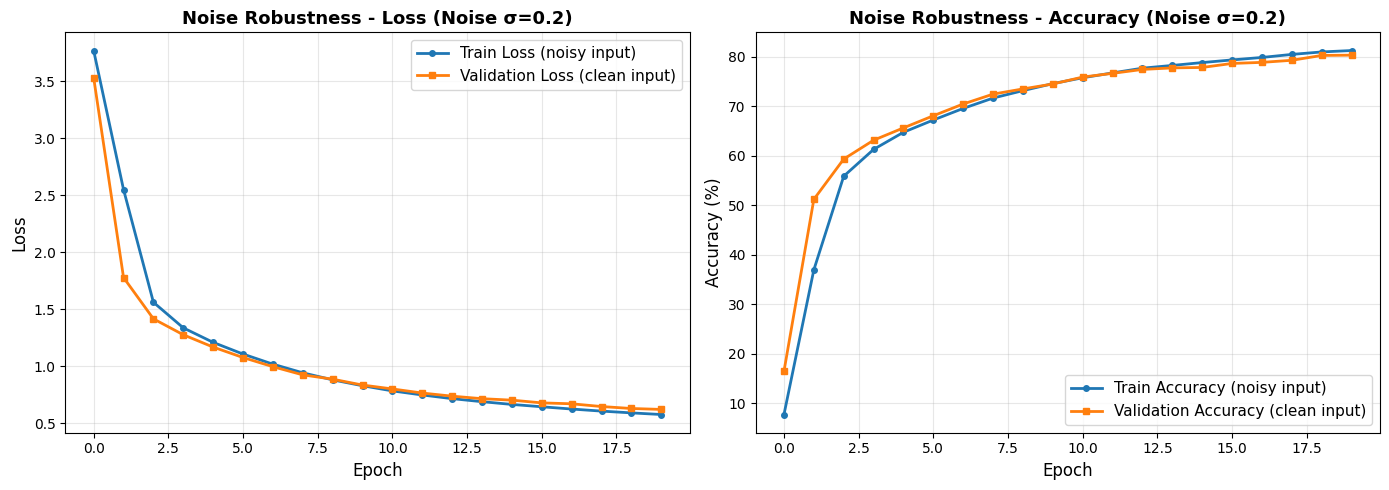

✓ Visualization complete

Note: Training on noisy data typically leads to lower accuracy
      on clean validation/test sets due to distribution mismatch.
      Dropout and BatchNorm can help mitigate this effect.


In [10]:
# ============================================================================
# VISUALIZATION - Noise Impact on Learning
# ============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(history['train_loss'], label='Train Loss (noisy input)', marker='o', markersize=4, linewidth=2, color='#1f77b4')
ax1.plot(history['val_loss'], label='Validation Loss (clean input)', marker='s', markersize=4, linewidth=2, color='#ff7f0e')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title(f'Noise Robustness - Loss (Noise σ={MASTER_CONFIG["gaussian_noise_std"]})', 
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(history['train_acc'], label='Train Accuracy (noisy input)', marker='o', markersize=4, linewidth=2, color='#1f77b4')
ax2.plot(history['val_acc'], label='Validation Accuracy (clean input)', marker='s', markersize=4, linewidth=2, color='#ff7f0e')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title(f'Noise Robustness - Accuracy (Noise σ={MASTER_CONFIG["gaussian_noise_std"]})', 
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('✓ Visualization complete')
print(f'\nNote: Training on noisy data typically leads to lower accuracy')
print(f'      on clean validation/test sets due to distribution mismatch.')
print(f'      Dropout and BatchNorm can help mitigate this effect.')